# Pipeline — từ CSV thô đến mô hình BiLSTM

Notebook này:
1. Đọc tất cả CSV trong `data/raw/Good Data/`.
2. **Remap nhãn** về dạng tiếng Việt sạch (xem `LABEL_REMAP`).
3. Cắt thành các window cố định `(20, 8)`.
4. Mã hoá cyclic cho `imu_x` → kết quả `(20, 9)`.
5. Encode label, shuffle, chia train/val/test (stratified).
6. Chuẩn hoá feature (fit trên train only).
7. Lưu dataset đã xử lý vào `data/processed/`.
8. Huấn luyện BiLSTM với **Stratified 5-Fold CV**.
9. Lưu mô hình vào `results/models/`.

Schema CSV nguồn: `flex1..flex5, imu_x, imu_y, imu_z, SIGN` (8 sensor + label, **không có `face`**).

## 1. Setup

In [1]:
import re
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

DATA_DIR    = PROJECT_ROOT / "data" / "raw" / "Good Data"
OUT_DIR     = PROJECT_ROOT / "data" / "processed"
RESULTS_DIR = PROJECT_ROOT / "results"
MODELS_DIR  = RESULTS_DIR / "models"
OUT_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

FEATURE_COLS = ["flex1", "flex2", "flex3", "flex4", "flex5", "imu_x", "imu_y", "imu_z"]
LABEL_COL    = "SIGN"

# ---- Label remap ----
# Key  = filename stem với phần `_<timestamp>` đã được strip (xem `file_label_key`).
# Value = nhãn sạch dùng để train. Nhãn in-file SIGN sẽ bị override bằng giá trị này.
# Strict: nếu thêm CSV mới mà thiếu mapping, pipeline sẽ raise KeyError.
LABEL_REMAP = {
    "baonhieu2": "bao nhiêu",
    "C":         "C",
    "khong_2":   "không",
    "O2":        "O",
    "pink4":     "pink",
    "tôi3":      "tôi",
    "xinchao0":  "xin chào",
    "C3":        "C",
    "xinchao2": "xin chào",
}

def file_label_key(path: Path) -> str:
    """Strip trailing `_<digits>` (timestamp) from filename stem.

    Examples:
        baonhieu2_1778907665.csv -> 'baonhieu2'
        khong_2_1778260100.csv   -> 'khong_2'
        C.csv                    -> 'C'
    """
    return re.sub(r"_\d+$", "", path.stem)

WINDOW_SIZE = 20
STRIDE      = 10

TEST_FRAC = 0.15
VAL_FRAC  = 0.15
SEED      = 42

# Training hyper-params
N_SPLITS   = 5
EPOCHS     = 200
BATCH_SIZE = 64

np.random.seed(SEED)
print(f"project root : {PROJECT_ROOT}")
print(f"data dir     : {DATA_DIR}")
print(f"out dir      : {OUT_DIR}")
print(f"models dir   : {MODELS_DIR}")
print(f"\nLABEL_REMAP keys -> values:")
for k, v in LABEL_REMAP.items():
    print(f"  {k:12s} -> {v!r}")

project root : /home/anchin/Projects/Sign-Language-Glove---AI
data dir     : /home/anchin/Projects/Sign-Language-Glove---AI/data/raw/Good Data
out dir      : /home/anchin/Projects/Sign-Language-Glove---AI/data/processed
models dir   : /home/anchin/Projects/Sign-Language-Glove---AI/results/models

LABEL_REMAP keys -> values:
  baonhieu2    -> 'bao nhiêu'
  C            -> 'C'
  khong_2      -> 'không'
  O2           -> 'O'
  pink4        -> 'pink'
  tôi3         -> 'tôi'
  xinchao0     -> 'xin chào'
  C3           -> 'C'
  xinchao2     -> 'xin chào'


## 2. Discover & inspect CSV files

Bảng dưới hiển thị cả nhãn in-file (trước remap) và nhãn sau remap, để kiểm tra `LABEL_REMAP` có khớp file không.

In [3]:
csv_paths = sorted(DATA_DIR.glob("*.csv"))
assert csv_paths, f"No CSVs found in {DATA_DIR}"

rows = []
missing = []
for p in csv_paths:
    df = pd.read_csv(p)
    key = file_label_key(p)
    mapped = LABEL_REMAP.get(key)
    if mapped is None:
        missing.append(p.name)
    rows.append({
        "file": p.name,
        "rows": len(df),
        "sign_in_file": df[LABEL_COL].unique().tolist(),
        "remap_key":   key,
        "remap_to":    mapped if mapped is not None else "(MISSING)",
        "has_nan": bool(df[FEATURE_COLS].isna().any().any()),
    })

if missing:
    print(f"!! Missing LABEL_REMAP entries for: {missing}")
pd.DataFrame(rows)

,file,rows,sign_in_file,remap_key,remap_to,has_nan
0,C.csv,3063,[test2],C,C,False
1,O2_1778259175.csv,3070,[O2],O2,O,False
2,baonhieu2_1778907665.csv,3067,[baonhieu2],baonhieu2,bao nhiêu,False
3,khong_2_1778260100.csv,4079,[khong?2],khong_2,không,False
4,pink4_1778909985.csv,1139,[pink4],pink4,pink,False
5,tôi3_1778496733.csv,3052,[tôi3],tôi3,tôi,False
6,xinchao0_1778908228.csv,3043,[xinchao0],xinchao0,xin chào,False


## 3. Cắt window

Mỗi recording được cắt thành các đoạn `(WINDOW_SIZE, 8)` với bước trượt `STRIDE`. **Trước khi cắt**, ta override cột `SIGN` của df bằng nhãn từ `LABEL_REMAP` — đảm bảo nhãn sạch và đồng nhất.

In [4]:
def window_recording(df: pd.DataFrame, window: int, stride: int):
    X_vals = df[FEATURE_COLS].to_numpy(dtype=np.float32)
    y_vals = df[LABEL_COL].to_numpy()
    X_out, y_out = [], []
    for start in range(0, len(df) - window + 1, stride):
        end = start + window
        win_labels = y_vals[start:end]
        if len(set(win_labels)) != 1:
            continue
        X_out.append(X_vals[start:end])
        y_out.append(win_labels[0])
    return np.stack(X_out), np.array(y_out)

In [5]:
X_list, y_list = [], []
for p in csv_paths:
    df = pd.read_csv(p)

    # Override in-file SIGN bằng nhãn sạch từ LABEL_REMAP (key = filename stem trừ timestamp).
    key = file_label_key(p)
    if key not in LABEL_REMAP:
        raise KeyError(f"No LABEL_REMAP entry for {p.name} (key={key!r})")
    df[LABEL_COL] = LABEL_REMAP[key]

    if df[FEATURE_COLS].isna().any().any():
        print(f"  ! NaNs in {p.name} - filling with column means")
        df[FEATURE_COLS] = df[FEATURE_COLS].fillna(df[FEATURE_COLS].mean())
    Xi, yi = window_recording(df, WINDOW_SIZE, STRIDE)
    X_list.append(Xi); y_list.append(yi)
    print(f"  {p.name:40s} -> {Xi.shape[0]:5d} windows   label={yi[0]!r}")

X = np.concatenate(X_list, axis=0)
y = np.concatenate(y_list, axis=0)
print(f"\nTotal windows: X={X.shape}   y={y.shape}")
print(f"Classes: {sorted(set(y))}")

  C.csv                                    ->   305 windows   label=np.str_('C')
  O2_1778259175.csv                        ->   306 windows   label=np.str_('O')
  baonhieu2_1778907665.csv                 ->   305 windows   label=np.str_('bao nhiêu')
  khong_2_1778260100.csv                   ->   406 windows   label=np.str_('không')
  pink4_1778909985.csv                     ->   112 windows   label=np.str_('pink')
  tôi3_1778496733.csv                      ->   304 windows   label=np.str_('tôi')
  xinchao0_1778908228.csv                  ->   303 windows   label=np.str_('xin chào')

Total windows: X=(2041, 20, 8)   y=(2041,)
Classes: [np.str_('C'), np.str_('O'), np.str_('bao nhiêu'), np.str_('không'), np.str_('pink'), np.str_('tôi'), np.str_('xin chào')]


## 4. Cyclic encoding của `imu_x`

`imu_x` là góc heading (đơn vị độ). Để tránh nhảy số khi đi qua 0°/360°, thay nó bằng cặp `(sin(imu_x), cos(imu_x))` — vị trí trên vòng tròn đơn vị.

**Lưu ý số feature**: spec gốc viết "8 feature sau khi sin/cos". Vì sin và cos là 2 biến độc lập, sau biến đổi ta có **9 feature**:

`flex1..5, imu_y, imu_z, sin_imu_x, cos_imu_x`

Model build với `input_shape = X.shape[1:]` nên tự khớp số feature thật.

In [6]:
imu_x_idx  = FEATURE_COLS.index("imu_x")
imu_x_rad  = np.deg2rad(X[:, :, imu_x_idx])
sin_x = np.sin(imu_x_rad)[..., None].astype(np.float32)
cos_x = np.cos(imu_x_rad)[..., None].astype(np.float32)

keep_idx = [i for i, c in enumerate(FEATURE_COLS) if c != "imu_x"]
X_kept   = X[:, :, keep_idx]
X        = np.concatenate([X_kept, sin_x, cos_x], axis=-1)

FEATURES_FINAL = [FEATURE_COLS[i] for i in keep_idx] + ["sin_imu_x", "cos_imu_x"]
print(f"X.shape after cyclic encoding: {X.shape}")
print(f"features (in order)          : {FEATURES_FINAL}")

X.shape after cyclic encoding: (2041, 20, 9)
features (in order)          : ['flex1', 'flex2', 'flex3', 'flex4', 'flex5', 'imu_y', 'imu_z', 'sin_imu_x', 'cos_imu_x']


## 5. Encode label & shuffle

In [7]:
le = LabelEncoder()
y_enc = le.fit_transform(y)
n_classes = len(le.classes_)
print("class -> id:")
for idx, cls in enumerate(le.classes_):
    print(f"  {idx}: {cls!r}")
print(f"\nn_classes = {n_classes}")

perm = np.random.permutation(len(X))
X, y_enc = X[perm], y_enc[perm]
print(f"shuffled. X={X.shape}  y={y_enc.shape}")

class -> id:
  0: np.str_('C')
  1: np.str_('O')
  2: np.str_('bao nhiêu')
  3: np.str_('không')
  4: np.str_('pink')
  5: np.str_('tôi')
  6: np.str_('xin chào')

n_classes = 7
shuffled. X=(2041, 20, 9)  y=(2041,)


## 6. Train / val / test split (stratified)

Test set giữ riêng cho evaluation cuối cùng; phần còn lại (train + val) sẽ được K-Fold trong bước 10.

In [8]:
X_tmp, X_test, y_tmp, y_test = train_test_split(
    X, y_enc, test_size=TEST_FRAC, stratify=y_enc, random_state=SEED,
)
X_train, X_val, y_train, y_val = train_test_split(
    X_tmp, y_tmp, test_size=VAL_FRAC, stratify=y_tmp, random_state=SEED,
)
print(f"train: {X_train.shape}   val: {X_val.shape}   test: {X_test.shape}")

train: (1473, 20, 9)   val: (261, 20, 9)   test: (307, 20, 9)


## 7. Chuẩn hoá feature

Fit `StandardScaler` **trên rows train**, apply lên tất cả split.

In [9]:
n_feat = X_train.shape[-1]
scaler = StandardScaler().fit(X_train.reshape(-1, n_feat))

def apply_scaler(arr):
    flat = scaler.transform(arr.reshape(-1, n_feat))
    return flat.reshape(arr.shape).astype(np.float32)

X_train = apply_scaler(X_train)
X_val   = apply_scaler(X_val)
X_test  = apply_scaler(X_test)

print("mean per feature :", np.round(scaler.mean_, 3))
print("scale per feature:", np.round(scaler.scale_, 3))

mean per feature : [ 2.2000e-02  3.3000e-02  6.6000e-02  4.7000e-02  4.0000e-03 -2.3853e+01
  6.3193e+01 -4.0400e-01  6.1500e-01]
scale per feature: [7.100e-02 2.400e-02 4.700e-02 4.100e-02 3.000e-03 1.884e+01 4.803e+01
 5.050e-01 4.510e-01]


## 8. Class distribution

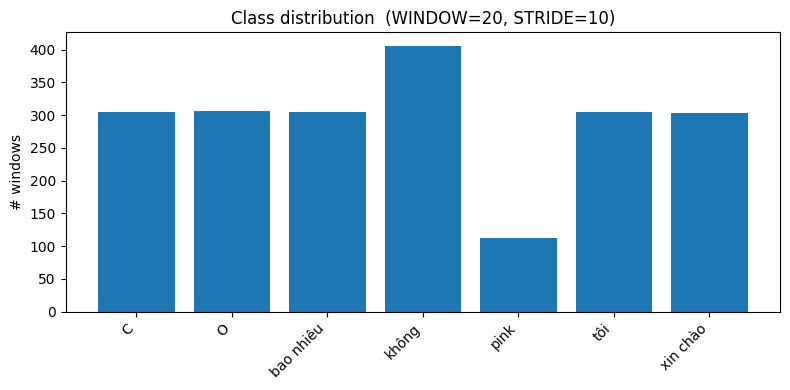

In [10]:
ids, counts = np.unique(y_enc, return_counts=True)
labels = [le.classes_[i] for i in ids]
plt.figure(figsize=(8, 4))
plt.bar(labels, counts)
plt.xticks(rotation=45, ha="right")
plt.ylabel("# windows")
plt.title(f"Class distribution  (WINDOW={WINDOW_SIZE}, STRIDE={STRIDE})")
plt.tight_layout(); plt.show()

## 9. Lưu dataset đã xử lý

In [11]:
np.save(OUT_DIR / "X_train.npy", X_train)
np.save(OUT_DIR / "y_train.npy", y_train)
np.save(OUT_DIR / "X_val.npy",   X_val)
np.save(OUT_DIR / "y_val.npy",   y_val)
np.save(OUT_DIR / "X_test.npy",  X_test)
np.save(OUT_DIR / "y_test.npy",  y_test)
np.save(OUT_DIR / "label_classes.npy", le.classes_)

# Copy label classes ra results/ để realtime_predict.py có thể load thẳng.
np.save(RESULTS_DIR / "label_classes.npy", le.classes_)

np.savez(
    OUT_DIR / "scaler.npz",
    mean=scaler.mean_,
    scale=scaler.scale_,
    feature_names=np.array(FEATURES_FINAL),
)

print(f"saved to {OUT_DIR}/")
for p in sorted(OUT_DIR.iterdir()):
    print(f"  {p.name:25s} {p.stat().st_size:>10d} bytes")

saved to /home/anchin/Projects/Sign-Language-Glove---AI/data/processed/
  .gitkeep                           0 bytes
  X_test.npy                    221168 bytes
  X_train.npy                  1060688 bytes
  X_val.npy                     188048 bytes
  label_classes.npy                380 bytes
  scaler.npz                      1230 bytes
  y_test.npy                      2584 bytes
  y_train.npy                    11912 bytes
  y_val.npy                       2216 bytes


## 10. Train BiLSTM với Stratified 5-Fold CV

Kiến trúc:

```
Input(20, n_feat)
  -> BatchNormalization
  -> Bidirectional(LSTM 64, return_sequences=True)
  -> Dropout(0.3)
  -> Bidirectional(LSTM 32, return_sequences=False)
  -> Dropout(0.3)
  -> Dense(32, ReLU)
  -> Dropout(0.2)
  -> Dense(n_classes, Softmax)
```

Optimizer **Adam(lr=1e-3)**; loss **sparse_categorical_crossentropy**.

Callbacks:
- `ReduceLROnPlateau`: monitor `val_loss`, patience=10, factor=0.5, min_lr=1e-5
- `EarlyStopping`: monitor `val_loss`, patience=20, `restore_best_weights=True`
- `ModelCheckpoint`: monitor `val_loss`, `save_best_only=True`, lưu mỗi fold

### 10.1 Build model

In [12]:
import tensorflow as tf
from tensorflow.keras import Input, Model
from tensorflow.keras.layers import (
    BatchNormalization, Bidirectional, LSTM, Dropout, Dense,
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    ReduceLROnPlateau, EarlyStopping, ModelCheckpoint,
)

def build_model(input_shape, n_classes: int) -> Model:
    inp = Input(shape=input_shape, name="frames")
    x = BatchNormalization(name="bn_in")(inp)
    x = Bidirectional(LSTM(64, return_sequences=True), name="bilstm_1")(x)
    x = Dropout(0.3, name="drop_1")(x)
    x = Bidirectional(LSTM(32, return_sequences=False), name="bilstm_2")(x)
    x = Dropout(0.3, name="drop_2")(x)
    x = Dense(32, activation="relu", name="dense_1")(x)
    x = Dropout(0.2, name="drop_3")(x)
    out = Dense(n_classes, activation="softmax", name="out")(x)
    model = Model(inp, out, name="glove_bilstm")
    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

# Sanity check architecture
build_model(X_train.shape[1:], n_classes).summary()

Model: "glove_bilstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ frames (InputLayer)             │ (None, 20, 9)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_in (BatchNormalization)      │ (None, 20, 9)          │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_1 (Bidirectional)        │ (None, 20, 128)        │        37,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_1 (Dropout)                │ (None, 20, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_2 (Bidirectional)        │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_2 (Dropout)                │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_3 (Dropout)                │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ out (Dense)                     │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 81,451 (318.17 KB)

 Trainable params: 81,433 (318.10 KB)

 Non-trainable params: 18 (72.00 B)

### 10.2 K-Fold training

Gộp `train + val` thành tập "full" (test giữ riêng). Split bằng **chỉ số sample** (không phải row index) — mỗi sample là 1 window shape `(20, n_feat)`. K=5 → train/val 80/20 mỗi fold.

In [13]:
X_full = np.concatenate([X_train, X_val], axis=0)
y_full = np.concatenate([y_train, y_val], axis=0)
sample_idx = np.arange(len(X_full))
print(f"X_full: {X_full.shape}   y_full: {y_full.shape}")
print(f"sample index range: 0..{len(sample_idx)-1}")

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

fold_histories = []
fold_val_loss  = []
fold_val_acc   = []

for fold, (tr_idx, va_idx) in enumerate(skf.split(sample_idx, y_full), start=1):
    print(f"\n{'='*60}\n  FOLD {fold}/{N_SPLITS}   train={len(tr_idx)}   val={len(va_idx)}\n{'='*60}")

    X_tr, X_va = X_full[tr_idx], X_full[va_idx]
    y_tr, y_va = y_full[tr_idx], y_full[va_idx]

    # Defensive reshape — đảm bảo shape (n_samples, 20, n_feat) đúng spec
    X_tr = X_tr.reshape(-1, WINDOW_SIZE, n_feat)
    X_va = X_va.reshape(-1, WINDOW_SIZE, n_feat)

    tf.keras.utils.set_random_seed(SEED + fold)
    model = build_model(X_tr.shape[1:], n_classes)

    ckpt_path = MODELS_DIR / f"model_fold_{fold}.h5"
    callbacks = [
        ReduceLROnPlateau(monitor="val_loss", patience=10, factor=0.5, min_lr=1e-5, verbose=1),
        EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True, verbose=1),
        ModelCheckpoint(str(ckpt_path), monitor="val_loss", save_best_only=True, verbose=0),
    ]

    history = model.fit(
        X_tr, y_tr,
        validation_data=(X_va, y_va),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=2,
    )

    best_vl = min(history.history["val_loss"])
    best_va = max(history.history["val_accuracy"])
    fold_histories.append(history.history)
    fold_val_loss.append(best_vl)
    fold_val_acc.append(best_va)
    print(f"  fold {fold}: best val_loss = {best_vl:.4f}   best val_acc = {best_va:.4f}")
    print(f"  saved -> {ckpt_path}")

# Chọn fold tốt nhất và copy thành model_best.h5
best_fold = int(np.argmin(fold_val_loss)) + 1
best_src  = MODELS_DIR / f"model_fold_{best_fold}.h5"
best_dst  = MODELS_DIR / "model_best.h5"
shutil.copy(best_src, best_dst)

print(f"\n{'='*60}\nCV SUMMARY\n{'='*60}")
for i, (vl, va) in enumerate(zip(fold_val_loss, fold_val_acc), 1):
    marker = "  <-- best" if i == best_fold else ""
    print(f"  fold {i}:  val_loss={vl:.4f}   val_acc={va:.4f}{marker}")
print(f"\nmean val_loss = {np.mean(fold_val_loss):.4f}  +/- {np.std(fold_val_loss):.4f}")
print(f"mean val_acc  = {np.mean(fold_val_acc):.4f}  +/- {np.std(fold_val_acc):.4f}")
print(f"\nbest fold -> {best_src.name}  (copied to {best_dst.name})")

X_full: (1734, 20, 9)   y_full: (1734,)
sample index range: 0..1733

  FOLD 1/5   train=1387   val=347
Epoch 1/200


22/22 - 5s - 243ms/step - accuracy: 0.6727 - loss: 1.3493 - val_accuracy: 0.8876 - val_loss: 0.7021 - learning_rate: 0.0010
Epoch 2/200


22/22 - 0s - 15ms/step - accuracy: 0.8991 - loss: 0.5080 - val_accuracy: 0.9568 - val_loss: 0.2003 - learning_rate: 0.0010
Epoch 3/200


22/22 - 0s - 12ms/step - accuracy: 0.9553 - loss: 0.2225 - val_accuracy: 0.9769 - val_loss: 0.0952 - learning_rate: 0.0010
Epoch 4/200


22/22 - 0s - 11ms/step - accuracy: 0.9820 - loss: 0.1135 - val_accuracy: 0.9827 - val_loss: 0.0571 - learning_rate: 0.0010
Epoch 5/200


...

22/22 - 0s - 15ms/step - accuracy: 0.9669 - loss: 0.1423 - val_accuracy: 0.9971 - val_loss: 0.0642 - learning_rate: 0.0010
Epoch 5/200


22/22 - 0s - 13ms/step - accuracy: 0.9805 - loss: 0.0944 - val_accuracy: 0.9971 - val_loss: 0.0450 - learning_rate: 0.0010
Epoch 6/200


22/22 - 0s - 12ms/step - accuracy: 0.9899 - loss: 0.0652 - val_accuracy: 0.9971 - val_loss: 0.0341 - learning_rate: 0.0010
Epoch 7/200


22/22 - 0s - 11ms/step - accuracy: 0.9899 - loss: 0.0489 - val_accuracy: 0.9971 - val_loss: 0.0318 - learning_rate: 0.0010
Epoch 8/200


22/22 - 0s - 12ms/step - accuracy: 0.9942 - loss: 0.0419 - val_accuracy: 0.9971 - val_loss: 0.0091 - learning_rate: 0.0010
Epoch 9/200
22/22 - 0s - 10ms/step - accuracy: 0.9978 - loss: 0.0270 - val_accuracy: 0.9971 - val_loss: 0.0173 - learning_rate: 0.0010
Epoch 10/200
22/22 - 0s - 10ms/step - accuracy: 0.9971 - loss: 0.0216 - val_accuracy: 0.9971 - val_loss: 0.0271 - learning_rate: 0.0010
Epoch 11/200
22/22 - 0s - 10ms/step - accuracy: 0.9993 - loss: 0.0156 - val_accuracy: 0.9971 - val_loss: 0.0216 - learning_rate: 0.0010
Epoch 12/200
22/22 - 0s - 14ms/step - accuracy: 0.9993 - loss: 0.0120 - val_accuracy: 0.9971 - val_loss: 0.0227 - learning_rate: 0.0010
Epoch 13/200
22/22 - 0s - 10ms/step - accuracy: 0.9993 - loss: 0.0117 - val_accuracy: 0.9971 - val_loss: 0.0198 - learning_rate: 0.0010
Epoch 14/200
22/22 - 0s - 10ms/step - accuracy: 0.9993 - loss: 0.0110 - val_accuracy: 0.9971 - val_loss: 0.0285 - learning_rate: 0.0010
Epoch 15/200
22/22 - 0s - 10ms/step - accuracy: 0.9993 - loss:

### 10.3 Training curves (mỗi fold)

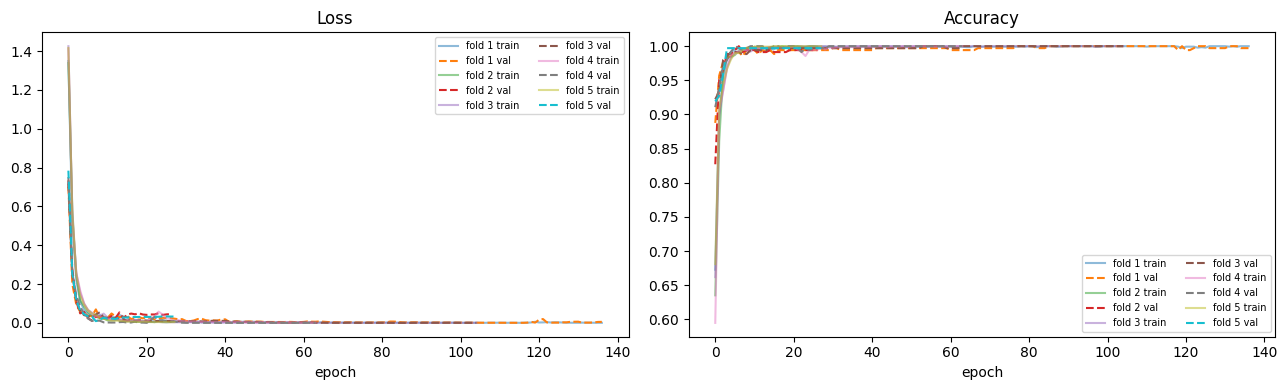

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for i, h in enumerate(fold_histories, 1):
    axes[0].plot(h["loss"],     label=f"fold {i} train", alpha=0.5)
    axes[0].plot(h["val_loss"], label=f"fold {i} val",   linestyle="--")
    axes[1].plot(h["accuracy"],     label=f"fold {i} train", alpha=0.5)
    axes[1].plot(h["val_accuracy"], label=f"fold {i} val",   linestyle="--")
axes[0].set_title("Loss");     axes[0].set_xlabel("epoch"); axes[0].legend(fontsize=7, ncol=2)
axes[1].set_title("Accuracy"); axes[1].set_xlabel("epoch"); axes[1].legend(fontsize=7, ncol=2)
plt.tight_layout(); plt.show()

### 10.4 Đánh giá trên test set (held-out)

In [15]:
from tensorflow.keras.models import load_model

best_model = load_model(MODELS_DIR / "model_best.h5")
test_loss, test_acc = best_model.evaluate(X_test, y_test, verbose=0)
print(f"test_loss = {test_loss:.4f}   test_acc = {test_acc:.4f}")

y_pred = np.argmax(best_model.predict(X_test, verbose=0), axis=1)
print("\nClassification report:\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))

test_loss = 0.0173   test_acc = 0.9935

Classification report:

              precision    recall  f1-score   support

           C       1.00      0.98      0.99        46
           O       0.98      1.00      0.99        46
   bao nhiêu       1.00      1.00      1.00        46
       không       1.00      1.00      1.00        61
        pink       1.00      1.00      1.00        17
         tôi       1.00      0.98      0.99        46
    xin chào       0.98      1.00      0.99        45

    accuracy                           0.99       307
   macro avg       0.99      0.99      0.99       307
weighted avg       0.99      0.99      0.99       307



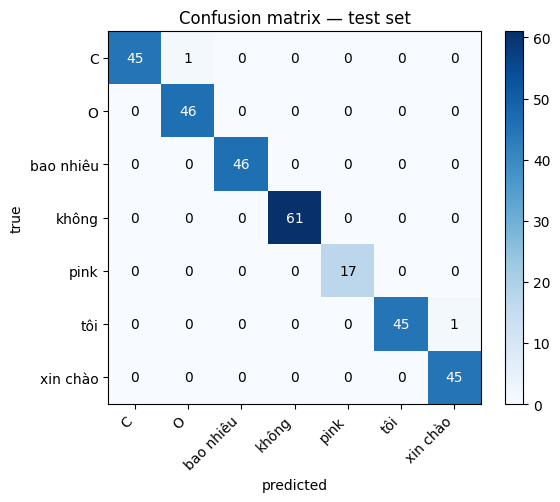

In [16]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(n_classes)); ax.set_xticklabels(le.classes_, rotation=45, ha="right")
ax.set_yticks(range(n_classes)); ax.set_yticklabels(le.classes_)
ax.set_xlabel("predicted"); ax.set_ylabel("true"); ax.set_title("Confusion matrix — test set")
for i in range(n_classes):
    for j in range(n_classes):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max()/2 else "black")
fig.colorbar(im, ax=ax); plt.tight_layout(); plt.show()